In [1]:
import torch
import supervision
import transformers
import pytorch_lightning
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [2]:
from transformers import DetrForObjectDetection, DetrImageProcessor

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = 'facebook/detr-resnet-50'

image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT)

Create the dataset

In [3]:
import os
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import ImageOps

class CreateDataset(Dataset):
    def __init__(self, images, annotations, image_dir, processor):
        self.images = images
        self.annotations = annotations
        self.image_dir = image_dir
        self.processor = processor

        self.image_id_to_annotations = {}
        for ann in annotations:
            self.image_id_to_annotations.setdefault(ann["image_id"], []).append(ann)
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_info = self.images[index]
        img_filename = os.path.basename(img_info["file_name"])
        img_path = os.path.join(self.image_dir, img_filename)
        image = Image.open(img_path).convert("RGB")
        image = ImageOps.exif_transpose(image).convert("RGB")

        anns = self.image_id_to_annotations.get(img_info["id"], [])

        target = {
            "image_id": img_info["id"],
            "annotations": anns
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt"
        )

        pixel_values = encoding["pixel_values"].squeeze()
        labels = encoding["labels"][0]

        return pixel_values, labels

In [4]:
import json

ANNOTATIONS_PATH = "/home/ncaytuir/data/ArchaIA_Project/DETRDataset/result.json"
IMAGES_DIR = "/home/ncaytuir/data/ArchaIA_Project/FilteredData"

with open(ANNOTATIONS_PATH) as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']
categories = coco_data['categories']

# Nao category_id to name
id2label = {cat["id"]: cat["name"] for cat in categories}
label2id = {v: k for k, v in id2label.items()}

In [5]:
print(id2label)
print(label2id)

{0: 'artifact', 1: 'color_card', 2: 'id_label', 3: 'scale_bar'}
{'artifact': 0, 'color_card': 1, 'id_label': 2, 'scale_bar': 3}


Split dataset

In [6]:
import random

random.seed(42)

image_ids = [img["id"] for img in images]
random.shuffle(image_ids)

split_idx = int(0.8 * len (image_ids))

train_ids = set(image_ids[:split_idx])
val_ids = set(image_ids[split_idx:])

train_images = [img for img in images if img["id"] in train_ids]
val_images = [img for img in images if img["id"] in val_ids]

train_annotations = [ann for ann in annotations if ann["image_id"] in train_ids]
val_annotations = [ann for ann in annotations if ann["image_id"] in val_ids]

print(f"Train: {len(train_images)} images")
print(f"Val: {len(val_images)} images")

Train: 242 images
Val: 61 images


Create data loaders

In [7]:
def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    return {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": labels
    }

train_dataset = CreateDataset(train_images, train_annotations, IMAGES_DIR, image_processor)
val_dataset = CreateDataset(val_images, val_annotations, IMAGES_DIR, image_processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    collate_fn=collate_fn,
    num_workers=4
)

In [8]:
i = 0
pixel_values, labels = train_dataset[i]

print("pixel_values:", pixel_values.shape, pixel_values.dtype)  # [3, H, W]
print("labels keys:", labels.keys())
print("boxes shape:", labels["boxes"].shape)          # [N, 4] (xyxy)
print("class_labels shape:", labels["class_labels"].shape)  # [N]
print("orig_size:", labels["orig_size"])
print("size:", labels["size"])

pixel_values: torch.Size([3, 800, 1200]) torch.float32
labels keys: KeysView({'size': tensor([ 800, 1200]), 'image_id': tensor([0]), 'class_labels': tensor([0, 3, 2]), 'boxes': tensor([[0.4658, 0.4756, 0.3236, 0.4435],
        [0.4616, 0.8068, 0.3710, 0.1688],
        [0.4905, 0.1827, 0.2111, 0.1004]]), 'area': tensor([137767.9062,  60103.5234,  20346.9824]), 'iscrowd': tensor([0, 0, 0]), 'orig_size': tensor([2912, 4368])})
boxes shape: torch.Size([3, 4])
class_labels shape: torch.Size([3])
orig_size: tensor([2912, 4368])
size: tensor([ 800, 1200])


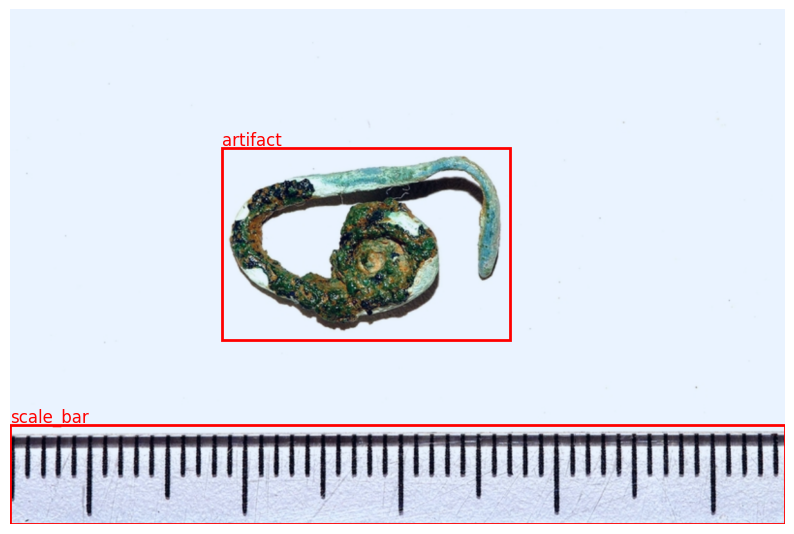

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torchvision.ops import box_convert

def show_dataset_sample(ds, idx=0):
    pixel_values, labels = ds[idx]  # pixel_values: [3,H,W]
    img = pixel_values.permute(1, 2, 0).cpu().numpy()

    # Reescalar para visualizar
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    H, W = img.shape[:2]

    boxes = labels["boxes"].cpu()  # puede ser cxcywh normalizado
    cls   = labels["class_labels"].cpu().numpy()

    # Si vienen normalizadas (0..1), pásalas a pixeles
    if boxes.numel() > 0 and boxes.max() <= 1.01:
        boxes = boxes * torch.tensor([W, H, W, H])

    # En DETR labels suelen estar en cxcywh -> convertimos a xyxy
    boxes_xyxy = box_convert(boxes, in_fmt="cxcywh", out_fmt="xyxy").numpy()

    fig, ax = plt.subplots(1, figsize=(10, 7))
    ax.imshow(img)

    for (x1, y1, x2, y2), c in zip(boxes_xyxy, cls):
        rect = patches.Rectangle(
            (x1, y1), max(1, x2 - x1), max(1, y2 - y1),
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 5), id2label[int(c)], color="red", fontsize=12)

    ax.set_axis_off()
    plt.show()

show_dataset_sample(train_dataset, idx=4)

In [10]:
batch = next(iter(train_loader))

print("pixel_values:", batch["pixel_values"].shape)  # [B, 3, H, W]
print("pixel_mask:", batch["pixel_mask"].shape)      # [B, H, W]
print("labels len:", len(batch["labels"]))           # B

print("labels[0] keys:", batch["labels"][0].keys())
print("labels[0] boxes:", batch["labels"][0]["boxes"].shape)

pixel_values: torch.Size([4, 3, 1059, 1333])
pixel_mask: torch.Size([4, 1059, 1333])
labels len: 4
labels[0] keys: KeysView({'size': tensor([1059,  800]), 'image_id': tensor([189]), 'class_labels': tensor([3, 0]), 'boxes': tensor([[0.5366, 0.8835, 0.6853, 0.2329],
        [0.5000, 0.3675, 1.0000, 0.7350]]), 'area': tensor([135234.0625, 622697.8750]), 'iscrowd': tensor([0, 0]), 'orig_size': tensor([1747, 1319])})
labels[0] boxes: torch.Size([2, 4])


In [11]:
empty_images = []

for img in train_images:
    img_id = img["id"]
    anns = [ann for ann in train_annotations if ann["image_id"] == img_id]
    if len(anns) == 0:
        empty_images.append(img_id)

print("Images with NO annotations:", len(empty_images))

Images with NO annotations: 0


In [12]:
import os

bad_images = []

for img in train_images:
    img_id = img["id"]
    anns = [ann for ann in train_annotations if ann["image_id"] == img_id]

    for ann in anns:
        x, y, w, h = ann["bbox"]

        if w <= 0 or h <= 0:
            bad_images.append(img_id)

print("Images with invalid boxes:", len(set(bad_images)))

Images with invalid boxes: 0


Fine-tune the model

In [13]:
import pytorch_lightning as pl
from transformers import DetrForObjectDetection

class Detr(pl.LightningModule):

    def __init__(self, lr, lr_backbone, weight_decay):
        super().__init__()
        self.model = DetrForObjectDetection.from_pretrained(
            pretrained_model_name_or_path=CHECKPOINT,
            num_labels=len(id2label),
            ignore_mismatched_sizes=True
        )

        self.lr = lr
        self.lr_backbone = lr_backbone
        self.weight_decay = weight_decay

    def on_train_start(self):
        self.model.train()

    def forward(self, pixel_values, pixel_mask):
        return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)
    
    def common_step(self, batch, batch_idx):
        pixel_values = batch["pixel_values"]
        pixel_mask = batch["pixel_mask"]
        labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]

        outputs = self.model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)

        loss = outputs.loss
        loss_dict = outputs.loss_dict

        return loss, loss_dict
    
    def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        bs = batch["pixel_values"].size(0)  
        # logs metrics for each training_step, and the average across the epoch
        self.log("training_loss", loss, prog_bar=True, batch_size=bs)
        for k,v in loss_dict.items():
            self.log("train_" + k, v.item(), batch_size=bs)

        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        bs = batch["pixel_values"].size(0)
        self.log("Validation/loss", loss, prog_bar=True, batch_size=bs)
        for k, v in loss_dict.items():
            self.log("validation_" + k, v.item(), batch_size=bs)
        
        return loss

    def configure_optimizers(self):
        # DETR authors decided to use different lr for backbone

        param_dicts = [
            {
                "params": [p for n, p in self.named_parameters() if "backbone" not in n and p.requires_grad]
            },
            {
                "params": [p for n, p in self.named_parameters() if "backbone" in n and p.requires_grad],
                "lr": self.lr_backbone,
            }
        ]
        return torch.optim.AdamW(param_dicts, lr=self.lr, weight_decay=self.weight_decay)
    
    def train_dataloader(self):
        return train_loader

    def val_dataloader(self):
        return val_loader

In [14]:
model = Detr(lr=1e-4, lr_backbone=1e-5, weight_decay=1e-4)

batch = next(iter(train_loader))
outputs = model(pixel_values=batch['pixel_values'], pixel_mask=batch['pixel_mask'])

/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpo

In [15]:
outputs.logits.shape

torch.Size([4, 100, 5])

In [16]:
from pytorch_lightning import Trainer

MAX_EPOCHS = 70

trainer = Trainer(devices=1, accelerator="gpu", max_epochs=MAX_EPOCHS, gradient_clip_val=0.1, accumulate_grad_batches=8, log_every_n_steps=5, enable_progress_bar=True, enable_model_summary=False,)

trainer.fit(model)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 
399 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this 
is intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=70` reached.


Inference on val/test dataset

In [17]:
model.to(DEVICE)

Detr(
  (model): DetrForObjectDetection(
    (model): DetrModel(
      (backbone): DetrConvModel(
        (conv_encoder): DetrConvEncoder(
          (model): FeatureListNet(
            (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
            (layer1): Sequential(
              (0): Bottleneck(
                (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (bn1): DetrFrozenBatchNorm2d()
                (act1): ReLU(inplace=True)
                (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                (bn2): DetrFrozenBatchNorm2d()
                (drop_block): Identity()
                (act2): ReLU(inplace=True)
                (aa): Identity()
                (conv3): Conv2d(64, 256

Image #260
Ground truth


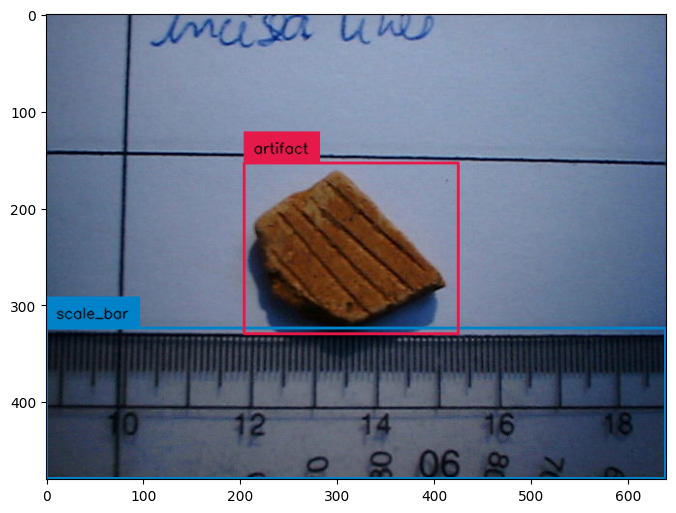

Detections


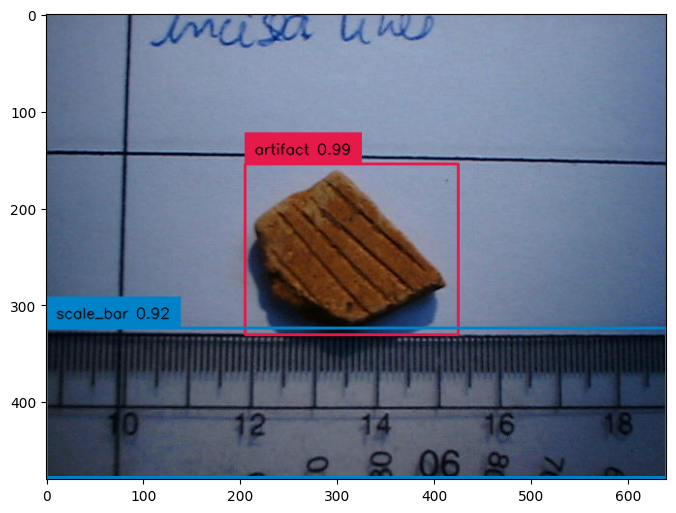

In [39]:
import supervision as sv
import cv2

box_annotator = sv.BoxAnnotator()

# image_id -> image_info
id2img = {img["id"]: img for img in images}

# image_id -> list[annotations]
ann_map = {}
for ann in annotations:
    ann_map.setdefault(ann["image_id"], []).append(ann)

# Select a random image
image_id = random.choice(list(id2img.keys()))
print(f"Image #{image_id}")

img_info = id2img[image_id]
img_filename = os.path.basename(img_info["file_name"]) 
image_path = os.path.join(IMAGES_DIR, img_filename)

image_bgr = cv2.imread(image_path)
assert image_bgr is not None, f"Could not read image: {image_path}"

# Load annotations for that image
img_anns = ann_map.get(image_id, [])

# Supervision expects COCO annotations lists with keys bboc/category_id
detections_gt = sv.Detections.from_coco_annotations(coco_annotation=img_anns)

labels_gt = []
for xyxy, _, class_id, _ in detections_gt:
    labels_gt.append(f"{id2label[int(class_id)]}")

frame_gt = box_annotator.annotate(
    scene=image_bgr.copy(),
    detections=detections_gt,
    labels=labels_gt
)

print("Ground truth")
sv.show_frame_in_notebook(frame_gt, (8, 8))

#### INFERENCE

with torch.no_grad():
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    inputs = image_processor(images=image_rgb, return_tensors="pt").to(DEVICE)
    outputs = model(**inputs)

    target_sizes = torch.tensor([image_rgb.shape[:2]], device=DEVICE)
    results = image_processor.post_process_object_detection(
        outputs=outputs,
        threshold=0.4, # change
        target_sizes=target_sizes
    )[0]

# Annotate predictions
detections_pred = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.5)

labels_pred = []
for xyxy, confidence, class_id, _ in detections_pred:
    labels_pred.append(f"{id2label[int(class_id)]} {float(confidence):.2f}")

frame_pred = box_annotator.annotate(
    scene=image_bgr.copy(),
    detections=detections_pred,
    labels=labels_pred
)

print("Detections")
sv.show_frame_in_notebook(frame_pred, (8, 8))

Evaluation on test/val dataset

In [23]:
def prepare_for_coco_detection(predictions):
    coco_results = []
    for original_id, prediction in predictions.items():
        if len(prediction) == 0:
            continue
            
        boxes = prediction["boxes"].clone()
        scores = prediction["scores"].tolist()
        labels = prediction["labels"].tolist()

        # convertir xyxy → xywh
        boxes[:, 2:] -= boxes[:, :2]

        boxes = boxes.tolist()

        coco_results.extend(
            [
                {
                    "image_id": original_id,
                    "category_id": labels[k],
                    "bbox": box,
                    "score": scores[k]
                }
                for k, box in enumerate(boxes)
            ]
        )
    return coco_results

In [24]:
from pycocotools.coco import COCO
from coco_eval import CocoEvaluator
from tqdm import tqdm

# Crear objeto COCO GT desde dict
coco_gt = COCO()
coco_gt.dataset = coco_data
coco_gt.createIndex()

evaluator = CocoEvaluator(coco_gt=coco_gt, iou_types=["bbox"])

print("Running inference")
model.eval()

for batch in tqdm(val_loader):
    pixel_values = batch["pixel_values"].to(DEVICE)
    pixel_mask = batch["pixel_mask"].to(DEVICE)
    labels = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch["labels"]]

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    original_target_sizes = torch.stack([target["orig_size"] for target in labels], dim=0)

    results = image_processor.post_process_object_detection(
        outputs, 
        threshold=0.5, #change 
        target_sizes=original_target_sizes
    )

    predictions = {
        target["image_id"].item(): output
        for target, output in zip(labels, results)
    }

    predictions = prepare_for_coco_detection(predictions)
    evaluator.update(predictions)

evaluator.synchronize_between_processes()
evaluator.accumulate()
evaluator.summarize()

creating index...
index created!
Running inference


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:03<00:00,  4.01it/s]

Accumulating evaluation results...
DONE (t=0.02s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.596
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.675
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.639
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.779
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.682
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.543
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.574
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.624
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.624
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.783
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.691
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= la

SAVE and LOAD model

In [25]:
model_path = os.path.join("/home/ncaytuir/data/ArchaIA_Project/Object-Detection/finetuned_models", '303artifacts_70epochs')

model.model.save_pretrained(model_path)

In [ ]:
image_processor.save_pretrained(model_path)

['/home/ncaytuir/data/ArchaIA_Project/Object-Detection/finetuned_models/303artifacts_70epochs/preprocessor_config.json']

: 

In [26]:
model = DetrForObjectDetection.from_pretrained(model_path)
model.to(DEVICE)

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      